# Direct Archive Access: bring your own archive

The Direct Archive Access module lets you load data from any local or remote archive of CDF files directly into Speasy — no web service required. You describe the file layout in a short YAML file and Speasy handles discovering and merging the files for any requested time range.

See the full reference at [Direct archive access](../user/direct_archive/direct_archive.rst).

## Only for Google Colab users

In [1]:
%pip install --upgrade ipympl speasy

/home/jeandet/.cache/uv/builds-v0/.tmpaCF7UB/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


In [2]:
try:
    from google.colab import output
    output.enable_custom_widget_manager()
except:
    print("Not running inside Google Collab")

Not running inside Google Collab


## For all users

### Step 1: describe the dataset in a YAML file

This example points Speasy at public THEMIS-A FGM data hosted at CDPP, with one CDF file per day. We write the YAML file directly to Speasy's user inventory directory — **without importing `speasy` yet**, since the inventory is only (re)built the first time `speasy` is imported in a process.

In [3]:
import os
import textwrap
import appdirs

inventory_dir = os.path.join(appdirs.user_config_dir(appname="speasy", appauthor="LPP"), "archive")
os.makedirs(inventory_dir, exist_ok=True)

yaml_content = textwrap.dedent(r"""
tha_fgm:
  inventory_path: my_data/THEMIS/THA
  master_cdf: http://cdpp.irap.omp.eu/themisdata/tha/l2/fgm/0000/tha_l2_fgm_00000000_v01.cdf
  split_frequency: daily
  split_rule: regular
  url_pattern: http://cdpp.irap.omp.eu/themisdata/tha/l2/fgm/{Y}/tha_l2_fgm_{Y}{M:02d}{D:02d}_v\d+.cdf
  use_file_list: true
""").strip()

yaml_path = os.path.join(inventory_dir, "themis_fgm_example.yaml")
with open(yaml_path, "w") as f:
    f.write(yaml_content)

print(f"Wrote {yaml_path}")

Wrote /home/jeandet/.config/speasy/archive/themis_fgm_example.yaml


### Step 2: import speasy and browse the new dataset

The dataset now appears in the inventory under `archive.my_data.THEMIS.THA.tha_fgm`, with its variables discovered automatically from the master CDF file:

In [4]:
import speasy as spz
%matplotlib inline
import matplotlib.pyplot as plt

tha_fgm = spz.inventories.data_tree.archive.my_data.THEMIS.THA.tha_fgm
tha_fgm

Legacy cache backup already present at /home/jeandet/.cache/speasy/Cache.diskcache.backup; skipping auto-migration. Move or remove it to retry.


Legacy cache backup already present at /home/jeandet/.local/share/speasy/index.diskcache.backup; skipping auto-migration. Move or remove it to retry.


You are using an incompatible proxy server http://sciqlop.lpp.polytechnique.fr/cache which is 0.13.5 while minimun required version is 0.14.0


<DatasetIndex: tha_fgm>

In [5]:
[v for v in dir(tha_fgm) if v.startswith("tha_fgl")]

['tha_fgl_btotal',
 'tha_fgl_btotalQ',
 'tha_fgl_dsl',
 'tha_fgl_dslQ',
 'tha_fgl_gse',
 'tha_fgl_gseQ',
 'tha_fgl_gsm',
 'tha_fgl_gsmQ',
 'tha_fgl_ssl',
 'tha_fgl_sslQ']

### Step 3: get_data() like any other product

In [6]:
tha_b = spz.get_data("archive/my_data/THEMIS/THA/tha_fgm/tha_fgl_btotal", "2018-06-01", "2018-06-02")
tha_b

SpeasyVariable(
    Name: 'tha_fgl_btotal', 
    Time Range: 2018-06-01T07:10:43.588134656 - 2018-06-01T17:34:43.525619456
    Shape: (599040, 1), 
    Unit: 'nT', 
    Columns: ['FGL-A B_total'], 
    Meta: {
        CATDESC: 'FGL magnetic field B magnitude ', 
        DISPLAY_TYPE: 'time_series', 
        FIELDNAM: 'FGL-A Magnetic Field, nT units', 
        FILLVAL: [-1.0000000150474662e+30], 
        UNITS: 'nT', 
        LABLAXIS: 'FGL-A B_total', 
        cdf_type: 'CDF_FLOAT', 
        spz_shape: 1, 
        FORMAT: 'E13.6', 
        DEPEND_TIME: 'tha_fgl_time', 
        DEPEND_EPOCH0: 'tha_fgl_epoch0', 
        DEPEND_0: 'tha_fgl_epoch16', 
        VALIDMIN: [0.0], 
        VALIDMAX: [25000.0], 
        VAR_TYPE: 'data', 
        TENSOR_ORDER: '0', 
        PROPERTY: 'scalar', 
        SC_ID: 'a', 
        VAR_NOTES: 'Units are in nanotesla', 
        AVG_TYPE: 'standard', 
        CALIB_SOFTWARE: 'fgm_calibrate, thm_cal_fgm, thm_cal_fit', 
        CALIB_INPUT: 'tha_fgmcal.txt',

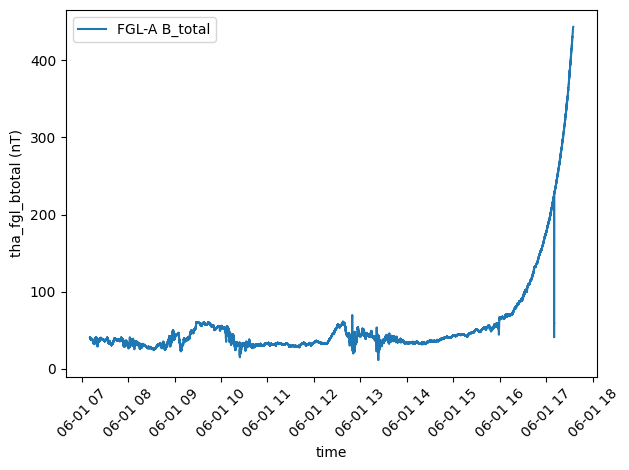

In [7]:
plt.figure()
tha_b.plot()
plt.tight_layout()
plt.show()

### Inline variables (no master file, no network access at import time)

If you'd rather avoid a master file entirely, you can describe each variable's metadata inline in the YAML instead — see the [inline variables section](../user/direct_archive/direct_archive.rst#quick-start-adding-a-dataset) of the reference page for the full syntax.